In [2]:
import glob, os

PATTERN = "results_pz_*_Lx_*_Nd_*_NT_*_with_err.npz"
files = sorted(glob.glob(PATTERN))

print(f"[info] matched files: {len(files)}")
for i, fn in enumerate(files):
    print(f"{i:3d}: {os.path.basename(fn)}")


[info] matched files: 8
  0: results_pz_0.0_Lx_10_Nd_1000_NT_3000_with_err.npz
  1: results_pz_0.0_Lx_12_Nd_1000_NT_4320_with_err.npz
  2: results_pz_0.0_Lx_14_Nd_1000_NT_5880_with_err.npz
  3: results_pz_0.0_Lx_16_Nd_1000_NT_7680_with_err.npz
  4: results_pz_0.0_Lx_18_Nd_1000_NT_9720_with_err.npz
  5: results_pz_0.0_Lx_20_Nd_500_NT_12000_with_err.npz
  6: results_pz_0.0_Lx_6_Nd_1000_NT_1080_with_err.npz
  7: results_pz_0.0_Lx_8_Nd_1000_NT_1920_with_err.npz


In [4]:
import re
import numpy as np

by_L = {}  # {Lx: (pg, var, var_err)}

for fn in files:
    m = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)", fn)
    print("m=",m)
    if not m:
        continue
    Lx = int(m.group(1))
    dat = np.load(fn)
    if {"pg","R2x_loop_var","R2x_loop_var_err"} <= set(dat.files):
        pg  = dat["pg"].astype(float)
        var = dat["R2x_loop_var"].astype(float)
        err = dat["R2x_loop_var_err"].astype(float)
        by_L[Lx] = (pg, var, err)
        print(f"L={Lx}, n={pg.size}, p:[{pg.min():.3f},{pg.max():.3f}]")


m= <re.Match object; span=(15, 36), match='Lx_10_Nd_1000_NT_3000'>
L=10, n=21, p:[0.600,0.800]
m= <re.Match object; span=(15, 36), match='Lx_12_Nd_1000_NT_4320'>
L=12, n=21, p:[0.600,0.800]
m= <re.Match object; span=(15, 36), match='Lx_14_Nd_1000_NT_5880'>
L=14, n=21, p:[0.600,0.800]
m= <re.Match object; span=(15, 36), match='Lx_16_Nd_1000_NT_7680'>
L=16, n=21, p:[0.600,0.800]
m= <re.Match object; span=(15, 36), match='Lx_18_Nd_1000_NT_9720'>
L=18, n=21, p:[0.600,0.800]
m= <re.Match object; span=(15, 36), match='Lx_20_Nd_500_NT_12000'>
L=20, n=21, p:[0.600,0.800]
m= <re.Match object; span=(15, 35), match='Lx_6_Nd_1000_NT_1080'>
L=6, n=21, p:[0.600,0.800]
m= <re.Match object; span=(15, 35), match='Lx_8_Nd_1000_NT_1920'>
L=8, n=21, p:[0.600,0.800]


In [5]:
for k in list(dat.files):
    arr = np.asarray(dat[k])
    print(f"  - {k:16s}: shape={arr.shape}, dtype={arr.dtype}")
    # 中身を安全にプレビュー
    if arr.ndim == 0:
        print("    value:", arr.item())
    elif arr.ndim == 1:
        print("    head:", arr[:5])
    else:
        print("    head:", arr[:2])   # 多次元なら先頭2行を表示


  - pg              : shape=(21,), dtype=float64
    head: [0.6  0.61 0.62 0.63 0.64]
  - TEE_ave         : shape=(21,), dtype=float64
    head: [ 0.006  0.005  0.001 -0.001 -0.006]
  - TEE_err         : shape=(21,), dtype=float64
    head: [0.00282347 0.00264234 0.00300133 0.00331813 0.00315816]
  - TEE_var         : shape=(21,), dtype=float64
    head: [0.007964 0.006975 0.008999 0.010999 0.009964]
  - R2x_ave         : shape=(21,), dtype=float64
    head: [0.39864286 0.37730357 0.3655     0.35075    0.32357143]
  - R2x_err         : shape=(21,), dtype=float64
    head: [0.003956   0.00386248 0.00388524 0.00380593 0.00372779]
  - R2x_var         : shape=(21,), dtype=float64
    head: [0.01563426 0.01490381 0.01508003 0.01447061 0.01388253]
  - R2z_ave         : shape=(21,), dtype=float64
    head: [0. 0. 0. 0. 0.]
  - R2z_err         : shape=(21,), dtype=float64
    head: [0. 0. 0. 0. 0.]
  - R2z_var         : shape=(21,), dtype=float64
    head: [0. 0. 0. 0. 0.]
  - R2x_loop_ave    

L=6, n=21, p:[0.600,0.800]
   p=0.600, var=9.990e-04, err=1.015e-03
   p=0.610, var=1.996e-03, err=9.894e-04
   p=0.620, var=6.951e-03, err=9.728e-04
L=8, n=21, p:[0.600,0.800]
   p=0.600, var=9.990e-04, err=7.129e-04
   p=0.610, var=1.996e-03, err=6.507e-04
   p=0.620, var=9.990e-04, err=6.909e-04
L=10, n=21, p:[0.600,0.800]
   p=0.600, var=0.000e+00, err=5.156e-04
   p=0.610, var=9.990e-04, err=5.070e-04
   p=0.620, var=0.000e+00, err=5.197e-04
L=12, n=21, p:[0.600,0.800]
   p=0.600, var=0.000e+00, err=4.289e-04
   p=0.610, var=0.000e+00, err=4.414e-04
   p=0.620, var=0.000e+00, err=4.266e-04
L=14, n=21, p:[0.600,0.800]
   p=0.600, var=0.000e+00, err=3.991e-04
   p=0.610, var=0.000e+00, err=3.670e-04
   p=0.620, var=0.000e+00, err=3.434e-04
L=16, n=21, p:[0.600,0.800]
   p=0.600, var=0.000e+00, err=3.228e-04
   p=0.610, var=0.000e+00, err=3.048e-04
   p=0.620, var=0.000e+00, err=3.141e-04
L=18, n=21, p:[0.600,0.800]
   p=0.600, var=0.000e+00, err=2.960e-04
   p=0.610, var=0.000e+00, 

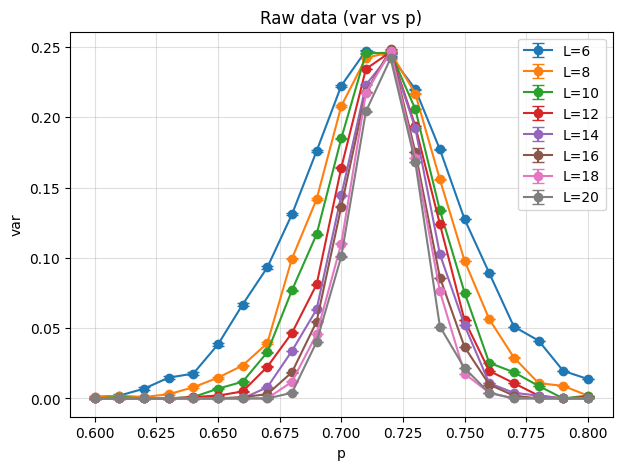

In [6]:
import matplotlib.pyplot as plt

# 1) 各Lごとの要約を表示
for L, (pg, var, err) in sorted(by_L.items()):
    print(f"L={L}, n={pg.size}, p:[{pg.min():.3f},{pg.max():.3f}]")
    # 代表的な先頭3点だけ表示
    for j in range(min(3, pg.size)):
        print(f"   p={pg[j]:.3f}, var={var[j]:.3e}, err={err[j]:.3e}")

# 2) Raw プロット
fig, ax = plt.subplots(figsize=(7,5))
for L, (pg, var, err) in sorted(by_L.items()):
    ax.errorbar(pg, var, err, fmt='o-', capsize=4, label=f"L={L}")
ax.set_xlabel("p")
ax.set_ylabel("var")
ax.set_title("Raw data (var vs p)")
ax.legend()
ax.grid(True, alpha=0.4)
plt.show()


In [7]:
import functools
import numpy as np

# すべての L の p 配列の共通部分を取る
p_lists = [by_L[L][0] for L in sorted(by_L)]
p_common = functools.reduce(np.intersect1d, p_lists)

print(p_lists)

print(f"完全一致する共通 p の数: {p_common.size}")
print("例:", p_common[:20])  # 最初の10点だけ表示


[array([0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ,
       0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ]), array([0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ,
       0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ]), array([0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ,
       0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ]), array([0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ,
       0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ]), array([0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ,
       0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ]), array([0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ,
       0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ]), array([0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 ,
       0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 ]), array

In [8]:
A_rows, dA_rows = [], []
for L in sorted(by_L):
    pg, var, err = by_L[L]
    # 共通点の位置を探す
    idx = np.nonzero(np.in1d(pg, p_common))[0]
    order = np.argsort(pg[idx])  # 昇順に並べ替え
    A_rows.append(var[idx][order])
    dA_rows.append(err[idx][order])

A = np.vstack(A_rows)   # (nL, nP)
dA = np.vstack(dA_rows)
rho = np.sort(p_common) # 共通 p 軸

print("A の形状:", A.shape)
print("rho の点数:", rho.size)


A の形状: (8, 21)
rho の点数: 21


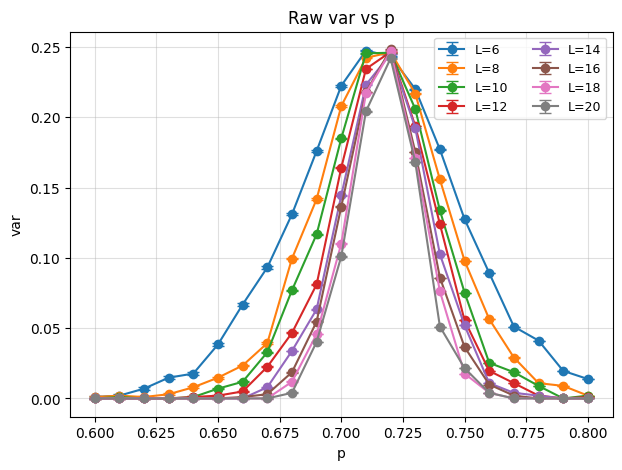

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
for L, (pg, var, err) in sorted(by_L.items()):
    ax.errorbar(pg, var, err,
                fmt='o-', capsize=4, elinewidth=1, capthick=1,
                label=f"L={L}")
ax.set_xlabel("p"); ax.set_ylabel("var"); ax.grid(True, alpha=0.4)
ax.set_title("Raw var vs p")
ax.legend(ncol=2, fontsize=9)
plt.show()


In [10]:
import numpy as np, functools

# --- 1) 全 L の pg の共通部分をとる ---
p_lists = [by_L[L][0] for L in sorted(by_L)]
p_common = functools.reduce(np.intersect1d, p_lists)
print(f"共通する p の数: {p_common.size}")
print("例:", p_common[:10])

# --- 2) 共通 p に合わせてデータを揃える ---
A_rows, dA_rows = [], []
for L in sorted(by_L):
    pg, var, err = by_L[L]
    # 共通点に該当する位置を探す
    idx = np.nonzero(np.in1d(pg, p_common))[0]
    order = np.argsort(pg[idx])  # 念のため昇順に並べ替え
    A_rows.append(var[idx][order])
    dA_rows.append(err[idx][order])

A = np.vstack(A_rows)   # (nL, nP)  ← 行=サイズ, 列=p
dA = np.vstack(dA_rows)
rho = np.sort(p_common) # 共通の p 軸

print("A.shape =", A.shape, "  rho.size =", rho.size)


共通する p の数: 21
例: [0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69]
A.shape = (8, 21)   rho.size = 21


In [11]:
import numpy as np
import fssa

# 行の並びに対応する L の配列（A, dA を作ったときと同じ順）
L_list = list(sorted(by_L))          # 例: [18, 24, 36, ...]
l = np.array(L_list, float)

# 初期値（そのままでOK）
argmax = np.argmax(A, axis=1)
pg_max = rho[argmax]
pc0 = float(np.mean(pg_max))
nu0, zeta0 = 1.3, 0.0

# 縮約（引数名に注意：l, rho, a, da, rho_c, nu, zeta）
sc = fssa.scaledata(l, rho, A, dA, pc0, nu0, zeta0)

# 評価関数 S
S = float(fssa.quality(sc.x, sc.y, sc.dy))
print(f"pc0={pc0:.6f}, nu0={nu0:.2f}, zeta0={zeta0:.2f},  S={S:.4f}")


pc0=0.718750, nu0=1.30, zeta0=0.00,  S=19245.7223


In [10]:
import numpy as np

any_bad = False
for L, (pg, var, err) in sorted(by_L.items()):
    neg_cnt = int(np.sum(err < 0))
    zero_cnt = int(np.sum(err == 0))
    nan_cnt = int(np.sum(~np.isfinite(err)))
    print(f"L={L}: min={np.nanmin(err):.3e}, max={np.nanmax(err):.3e}, "
          f"neg={neg_cnt}, zero={zero_cnt}, nan/inf={nan_cnt}")
    if neg_cnt > 0 or zero_cnt > 0 or nan_cnt > 0:
        any_bad = True

if not any_bad:
    print("[OK] すべての L で err は正の有限値です。")
else:
    print("[WARN] どこかに負/ゼロ/NaN の誤差があります。上の行で確認してください。")


L=6: min=0.000e+00, max=1.119e-02, neg=0, zero=1, nan/inf=0
L=8: min=0.000e+00, max=1.111e-02, neg=0, zero=5, nan/inf=0
L=10: min=0.000e+00, max=1.135e-02, neg=0, zero=6, nan/inf=0
L=12: min=0.000e+00, max=1.206e-02, neg=0, zero=4, nan/inf=0
L=14: min=0.000e+00, max=1.242e-02, neg=0, zero=6, nan/inf=0
L=16: min=0.000e+00, max=1.158e-02, neg=0, zero=5, nan/inf=0
L=18: min=0.000e+00, max=1.147e-02, neg=0, zero=6, nan/inf=0
L=20: min=0.000e+00, max=1.144e-02, neg=0, zero=7, nan/inf=0
L=22: min=0.000e+00, max=1.288e-02, neg=0, zero=8, nan/inf=0
[WARN] どこかに負/ゼロ/NaN の誤差があります。上の行で確認してください。
